In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('Student Social Media And Mental Health Impact.csv')
print(df.head())

   Age  Gender Country Academic_Level Most_Used_Platform Purpose_Of_Use  \
0   21    Male   Other  Undergraduate           Facebook     Networking   
1   23  Female   Other       Graduate           LinkedIn      Education   
2   22    Male  Canada  Undergraduate          Instagram  Entertainment   
3   18    Male   Other    High School           Snapchat  Entertainment   
4   24  Female   Other       Graduate           Facebook     Networking   

   Avg_Daily_Usage_Hours  Daily_Unlocks  Study_Hours  Physical_Activity_Hours  \
0                    4.0            134          4.5                      2.2   
1                    1.6             73          7.0                      2.4   
2                    4.6            166          4.0                      1.8   
3                    7.0            220          1.0                      1.7   
4                    7.5            237          1.0                      1.1   

   Sleep_Hours_Per_Night Stress_Level  Mental_Health_Score  
0

In [ ]:
df.shape

(5000, 13)

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4998 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4998 non-null   int64  
 1   Gender                   4998 non-null   object 
 2   Country                  4998 non-null   object 
 3   Academic_Level           4998 non-null   object 
 4   Most_Used_Platform       4998 non-null   object 
 5   Purpose_Of_Use           4998 non-null   object 
 6   Avg_Daily_Usage_Hours    4998 non-null   float64
 7   Daily_Unlocks            4998 non-null   int64  
 8   Study_Hours              4998 non-null   float64
 9   Physical_Activity_Hours  4998 non-null   float64
 10  Sleep_Hours_Per_Night    4998 non-null   float64
 11  Stress_Level             4998 non-null   object 
 12  Mental_Health_Score      4998 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 546.7+ KB


In [ ]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


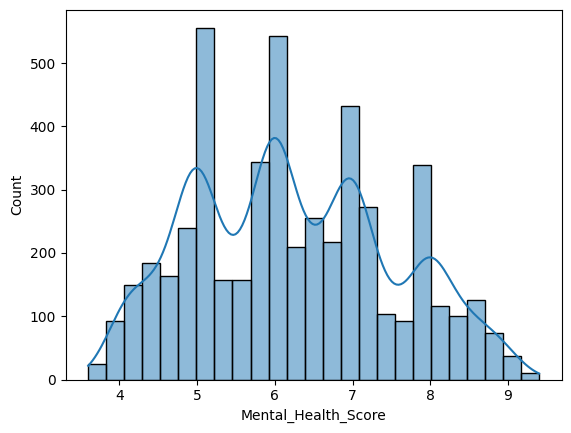

In [ ]:
sns.histplot(df['Mental_Health_Score'],kde=True)
plt.show()

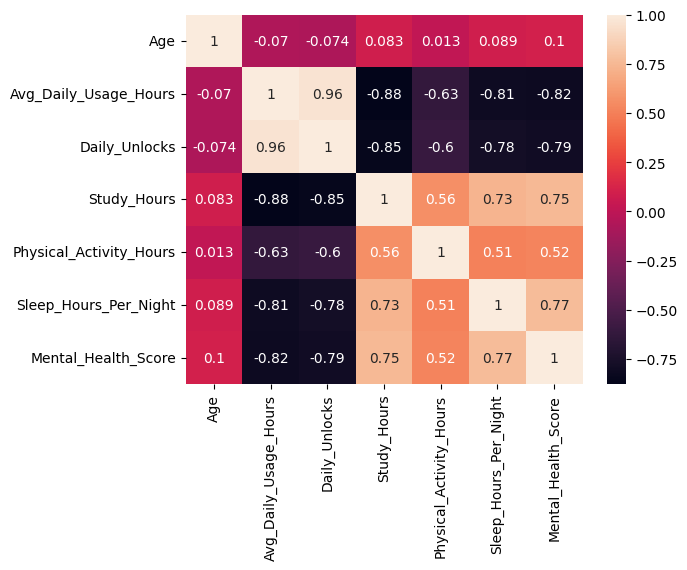

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
# stress level vs mental_health
df['Stress_Level'].value_counts()
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

In [ ]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

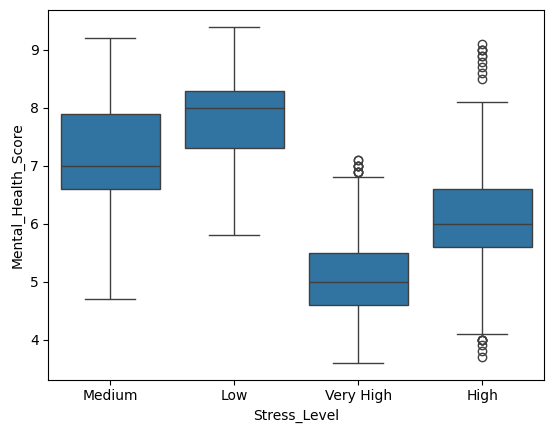

In [ ]:
order=['low','medium','high','very high']
sns.boxplot(x='Stress_Level',y='Mental_Health_Score',data=df)
plt.show()

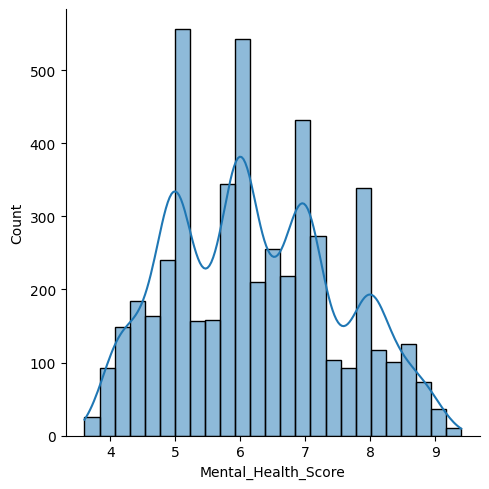

In [ ]:
sns.displot(df['Mental_Health_Score'],kde=True)
plt.show()

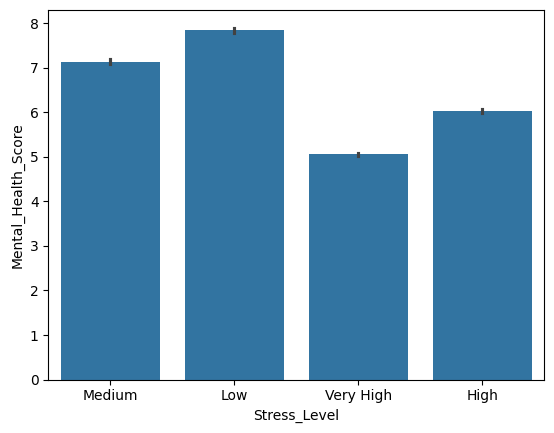

In [ ]:
sns.barplot(x='Stress_Level',y='Mental_Health_Score',data=df)
plt.show()

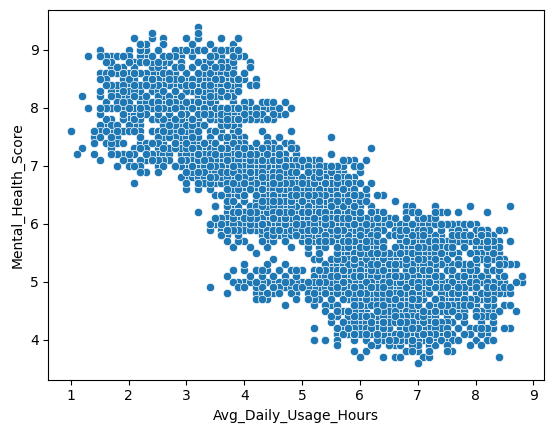

In [ ]:
sns.scatterplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',data=df)
plt.show()

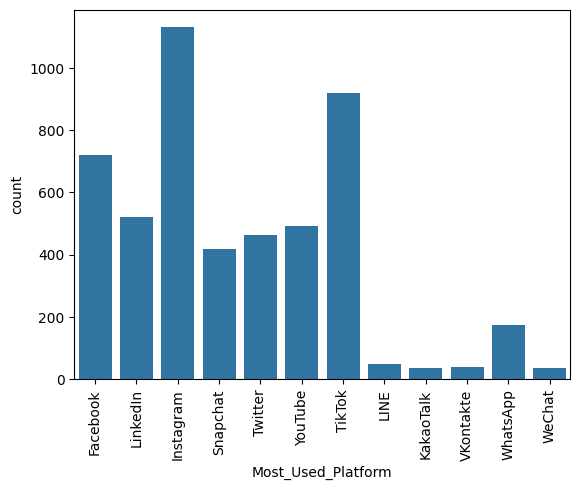

In [ ]:
sns.countplot(x='Most_Used_Platform',data=df)
plt.xticks(rotation=90)
plt.show()

checking outlier

In [ ]:
num_feature=df.select_dtypes(include=['number'])
Q1=num_feature.quantile(0.25)
Q3=num_feature.quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=num_feature[(num_feature<(lower_bound))|(num_feature>(upper_bound))]
print(outliers)


      Age  Avg_Daily_Usage_Hours  Daily_Unlocks  Study_Hours  \
0     NaN                    NaN            NaN          NaN   
1     NaN                    NaN            NaN          NaN   
2     NaN                    NaN            NaN          NaN   
3     NaN                    NaN            NaN          NaN   
4     NaN                    NaN            NaN          NaN   
...   ...                    ...            ...          ...   
4995  NaN                    NaN            NaN          NaN   
4996  NaN                    NaN            NaN          NaN   
4997  NaN                    NaN            NaN          NaN   
4998  NaN                    NaN            NaN          NaN   
4999  NaN                    NaN            NaN          NaN   

      Physical_Activity_Hours  Sleep_Hours_Per_Night  Mental_Health_Score  
0                         NaN                    NaN                  NaN  
1                         NaN                    NaN                  NaN  
2  

Data Cleaning

In [ ]:
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

skewness

In [ ]:
num_col=df.select_dtypes(include='number')
num_col.skew()
# near to 0 ->centralized
# near to -1.56 ->left skewed
# near to 1.26-> rihjt skewed

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


feature Engineering

In [ ]:
top_countries=df['Country'].value_counts().index[0:10].tolist()
print(top_countries)

['Other', 'India', 'USA', 'Canada', 'Australia', 'UK', 'Germany', 'Mexico', 'Turkey', 'France']


In [ ]:
def group_countries(Country):
  if Country in top_countries:
    return Country
  else:
    return 'other'


In [ ]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'other'

In [ ]:
df['Grouped_Country']=df['Country'].apply(group_countries)
df['Grouped_Country'].value_counts()


,count
Grouped_Country,
Other,1879
other,1352
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94


In [ ]:
from sklearn.model_selection import train_test_split
skew_col = ['Study_Hours'] # use ->log transformation
# Corrected: Exclude 'Mental_Health_Score' from other_num_col as it is the target variable
other_num_col = ['Age','Avg_Daily_Usage_Hours','Sleep_Hours_Per_Night','Physical_Activity_Hours','Daily_Unlocks'] # use->Standard_Scaler
ordinal_col = ['Stress_Level'] # use->ordinal_encoding
normal_col = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_Country"] # use-> One Hot Encoding
all_feature_columns = skew_col + other_num_col + ordinal_col + normal_col
x = df[all_feature_columns]
y = df['Mental_Health_Score']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

pipelines in machine learning


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler,OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
# skewed pipeline
skew_pipeline=Pipeline(steps=[
    ('log_transform',FunctionTransformer(np.log1p))
    ,('scale',StandardScaler())
    ])
# numeric feature
plain_numeric_pipeline=Pipeline(steps=[
    ('scale',StandardScaler())
])
# ordinal pipeline
ordinal_pipeline=Pipeline(steps=[
    ('ordinal',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
])
# nominal pipeline
nominal_pipeline=Pipeline(steps=[
    ('one hot',OneHotEncoder(handle_unknown='ignore'))
])

# handling konsa feature konsa pipeline m jayega
preprocessing=ColumnTransformer(transformers=[
    ('skewed_pipeline',skew_pipeline,skew_col),
    ('numeric_pipeline',plain_numeric_pipeline,other_num_col),
    ('ordinal',ordinal_pipeline,ordinal_col),
    ('nominal',nominal_pipeline,normal_col)
])

# model building and **pipeline**



In [ ]:
from sklearn import pipeline
from sklearn.linear_model import LinearRegression
lr_pipeline=Pipeline(steps=[
    ('preprocessing',preprocessing),
    ('model',LinearRegression())
])

## training model

In [ ]:
lr_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('skewed_pipeline',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('numeric_pipeline',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Sleep_Hours_Per_Night',
                                                   'Physical_Activity_Hours',
                                                   'Daily_Unlocks']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('nominal',
                                                  Pipeline(steps=[('one hot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use',
                                                   'Grouped_Country'])])),
                ('model', LinearRegression())])

In [ ]:
pred_test=lr_pipeline.predict(x_test)
pred_train=lr_pipeline.predict(x_train)

# model **evaluation**

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
lr_r2_test=r2_score(y_test,pred_test)
print(f"accuracy of testing {lr_r2_test}")
lr_r2_train=r2_score(y_train,pred_train)
print(f"accuracy of training {lr_r2_train}")
#

accuracy of testing 0.7485643049633411
accuracy of training 0.733095608993116


# creating random forest pipeline

In [ ]:
from sklearn import pipeline
from sklearn.ensemble import RandomForestRegressor
rf_pipeline=Pipeline(steps=[
    ('preprocessing',preprocessing),
    ('model',RandomForestRegressor())
])
rf_pipeline.fit(x_train,y_train)
pred_test=rf_pipeline.predict(x_test)
pred_train=rf_pipeline.predict(x_train)
rf_r2=r2_score(y_test,pred_test)
print(f"accuracy of testing {rf_r2}")
rf_r2_train=r2_score(y_train,pred_train)
print(f"accuracy of training {rf_r2_train}")
#

accuracy of testing 0.9007414475960108
accuracy of training 0.9835899311132162


# Hyperparameter Tunning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
param_grid={
    'model__n_estimators':[100,200,300],
    'model__min_samples_leaf':[1,2,4],
    'model__max_depth':[5,10,15],
    'model__min_samples_split':[2,5,10]
}

random_search=RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=19,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
random_search.fit(x_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('skewed_pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('numeric_pipeline',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Sleep_Hours_Pe...
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['Gender',
                                                                                'Academic_Level',
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_Country'])])),
                                             ('model',
                                              RandomForestRegressor())]),
                   n_iter=19, n_jobs=-1,
                   param_distributions={'model__max_depth': [5, 10, 15],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2')

In [ ]:
random_search.best_params_

{'model__n_estimators': 200,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 1,
 'model__max_depth': 15}

In [ ]:
rf_best_pipeline=random_search.best_estimator_
rf_best_preds=rf_best_pipeline.predict(x_test)
rf_best_r2=r2_score(y_test,rf_best_preds)
print(f"accuracy of testing {rf_best_r2}")

accuracy of testing 0.8949341239323864


In [ ]:
import joblib
